In [13]:
import numpy as np
from pathlib import Path

DATA_PATH = Path().resolve().parent.parent / "data" 
DATASET = "mnist" 

In [14]:
train_np = np.load(DATA_PATH / DATASET / "train.npz")
print(train_np)
images = train_np["img"]
labels = train_np["label"]
images = images.squeeze(-1)


NpzFile '/home/sebastian/dev/mine/liquid/data/mnist/train.npz' with keys: img, label


In [15]:
images_flatten = images.reshape([images.shape[0], images.shape[1] * images.shape[1]])
images_flatten.shape

(60000, 784)

In [16]:
#Run training of a ensemble
import sys 
import jax
import jax.numpy as jnp
sys.path.insert(0, '/home/sebastian/dev/mine/liquid/liquid_jax')
from learner_mnist_le import LeMnistLearner, LeMlp, DeModelMlp
from liquid_solver import LEsolver, LEInfo
from structs import TrainParams
from mnist import Mnist
from pathlib import Path
from run_ablation_experiment import train, plot_losses, loss_fn, train_batch
from datetime import datetime


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]


['validation_loss', 'validation_ce_loss', 'validation_load_distribution_loss', 'validation_specialization_losss', 'loss', 'ce_loss', 'load_distribution_loss', 'specialization_losss']
saving to/home/sebastian/dev/mine/liquid/liquid_jax/notebooks/experiments/ablation/20260312_173231


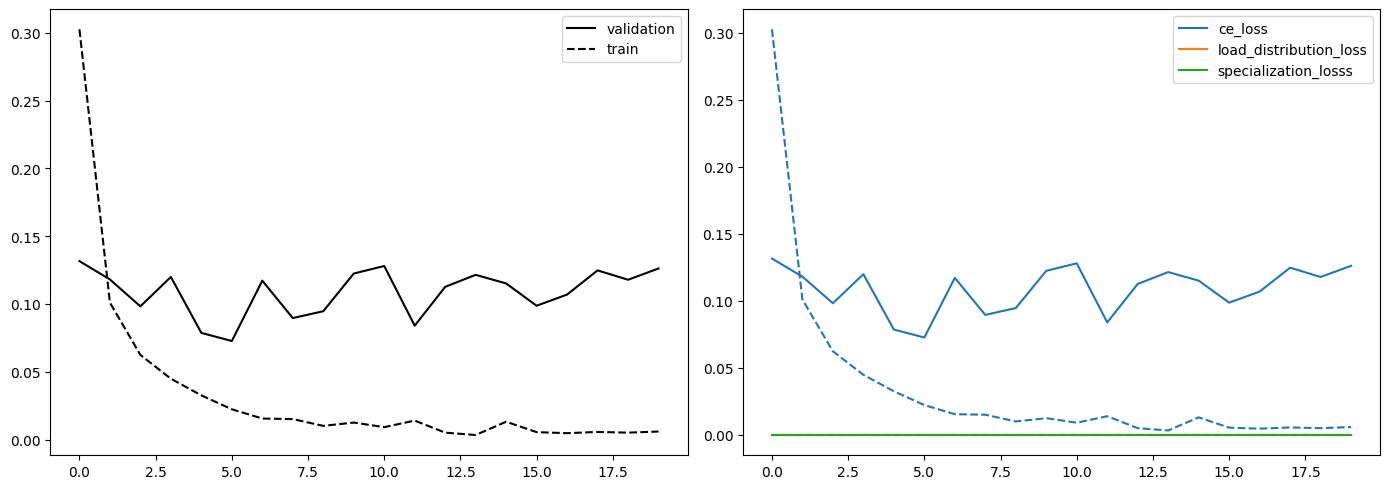

In [ ]:
key = jax.random.key(42)

Mnist.folder = folder = Path().resolve().parent.parent / "data" / "mnist"
params = TrainParams(
    batch_size=512,
    preload_batches_to_gpu=5,
    valid_batches=2,
    epochs=20,
    lr=1e-3,
    optimizer="adam",
    performance_loss="ce",
    task=Mnist,
    learner=LeMnistLearner
)

metrics = train(key, params)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")      
output_path = Path().resolve() / "experiments" / "ablation" / timestamp                                                                                                              
plot_losses(output_path, metrics, save=False)

In [ ]:
boddy_hidd_dim = 128

model = LeMnistLearner.get_model()
model

LeMlp(
    # attributes
    n_models = 10
    out = (32, 10)
    delegation = (32, 10)
    body = (128, 64)
)

In [19]:
print(images_flatten.shape)
print(labels.shape)

(60000, 784)
(60000,)


In [20]:
def count_params(input_dim, body, out, delegation):                                                                                                                                                                                                      
      """Count parameters per component for a single expert."""                                                                                                                                                                                            
      def _layers(in_dim, neurons):                                                                                                                                                                                                                        
          total, prev = 0, in_dim                                                                                                                                                                                                                        
          for n in neurons:
              total += prev * n + n  # weights + bias
              prev = n
          return total

      body_out = body[-1] if body else input_dim
      bp = _layers(input_dim, body) if body else 0
      op = _layers(body_out, out)
      dp = _layers(body_out, delegation)
      return {"body": bp, "out": op, "del": dp, "total": bp + op + dp}

In [21]:
count_params(784, body=(128, 64), out=(32, 10), delegation=(32, 10))

{'body': 108736, 'out': 2410, 'del': 2410, 'total': 113556}

In [22]:
def solve_hidden_dims(total_budget, body_pct, out_pct, del_pct,
                        input_dim=784, body_out=64, n_classes=10, n_models=10):
      """Solve for hidden widths given a param budget and percentages."""
      # params = h * (in + 1 + out) + out  →  h = (budget - out) / (in + 1 + out)
      h_body = int((total_budget * body_pct - body_out) / (input_dim + 1 + body_out))
      h_out  = int((total_budget * out_pct - n_classes) / (body_out + 1 + n_classes))
      h_del  = int((total_budget * del_pct - n_models) / (body_out + 1 + n_models))

      print(f"h_body={h_body}, h_out={h_out}, h_del={h_del}")

      body = (h_body, body_out)
      out = (h_out, n_classes)
      delegation = (h_del, n_models)
      return body, out, delegation

In [23]:
body, out, deleg = solve_hidden_dims(5000, body_pct=0.10, out_pct=0.40, del_pct=0.50)

h_body=0, h_out=26, h_del=33


In [2]:
import pandas as pd

df = pd.read_parquet("/home/s6019595/liquid/experiments/ablation/20260313_122246/results.parquet")

In [7]:
df.head(10)

,h_body,h_out,h_del,body,out,delegation,skip,actual_params,body_params,head_in,final_val_loss,final_train_loss,best_val_loss,best_val_ce_loss,final_val_ce_loss
0,0,31,31,None,"[31, 10]","[31, 10]",False,49310,0,784,0.121927,0.005972,0.084279,0.084279,0.121927
1,1,327,327,"[1, 64]","[327, 10]","[327, 10]",False,49983,913,64,0.182051,0.161612,0.169660,0.169660,0.182051
2,6,299,299,"[6, 64]","[299, 10]","[299, 10]",False,50028,5158,64,0.136119,0.014316,0.085695,0.085695,0.136119
3,11,271,271,"[11, 64]","[271, 10]","[271, 10]",False,50073,9403,64,0.120828,0.007793,0.067708,0.067708,0.120828
4,16,242,242,"[16, 64]","[242, 10]","[242, 10]",False,49968,13648,64,0.140987,0.009862,0.072545,0.072545,0.140987
5,21,214,214,"[21, 64]","[214, 10]","[214, 10]",False,50013,17893,64,0.109594,0.002667,0.075784,0.075784,0.109594
6,26,186,186,"[26, 64]","[186, 10]","[186, 10]",False,50058,22138,64,0.108159,0.005360,0.086864,0.086864,0.108159
7,31,157,157,"[31, 64]","[157, 10]","[157, 10]",False,49953,26383,64,0.145752,0.008910,0.083249,0.083249,0.145752
8,36,129,129,"[36, 64]","[129, 10]","[129, 10]",False,49998,30628,64,0.080815,0.010682,0.074239,0.074239,0.080815
9,41,101,101,"[41, 64]","[101, 10]","[101, 10]",False,50043,34873,64,0.073138,0.000118,0.068163,0.068163,0.073138
